# TP 3.2 : Modélisation, Modèle linéaire et ANOVA

## 1. Régression linéaire simple

Pour ce premier exercice, nous manipulerons le jeu de données `cars`.

In [1]:
help(cars)

cars                 package:datasets                  R Documentation

_S_p_e_e_d _a_n_d _S_t_o_p_p_i_n_g _D_i_s_t_a_n_c_e_s _o_f _C_a_r_s

_D_e_s_c_r_i_p_t_i_o_n:

     The data give the speed of cars and the distances taken to stop.
     Note that the data were recorded in the 1920s.

_U_s_a_g_e:

     cars
     
_F_o_r_m_a_t:

     A data frame with 50 observations on 2 variables.

       [,1]  speed  numeric  Speed (mph)            
       [,2]  dist   numeric  Stopping distance (ft) 
      
_S_o_u_r_c_e:

     Ezekiel, M. (1930) _Methods of Correlation Analysis_.  Wiley.

_R_e_f_e_r_e_n_c_e_s:

     McNeil, D. R. (1977) _Interactive Data Analysis_.  Wiley.

_E_x_a_m_p_l_e_s:

     require(stats); require(graphics)
     plot(cars, xlab = "Speed (mph)", ylab = "Stopping distance (ft)",
          las = 1)
     lines(lowess(cars$speed, cars$dist, f = 2/3, iter = 3), col = "red")
     title(main = "cars data"

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>À partir des formules rappelées en cours, calculer l'équation de la droite de régression de <code>cars&dollar;dist</code> en fonction de <code>cars&dollar;speed</code>.</li>
        <li>Retrouver ce résultat directement grâce à la fonction <code>lm()</code>.</li>
        <li>Calculer la part de variance expliquée par le modèle en fonction du rapport de la variance des résidus sur la variance initiale. Cette quantité s'appelle <i>coefficient de détermination linéaire de Pearson</i> ou plus simplement $R^2$.</li>
        <li>Représenter graphiquement le nuage de points des données traversé par la droite de régression.<br>
            <center><img src="img/regression_simple.png"></center>
        </li>
    </ol>
</div>

[1] 0.8068949

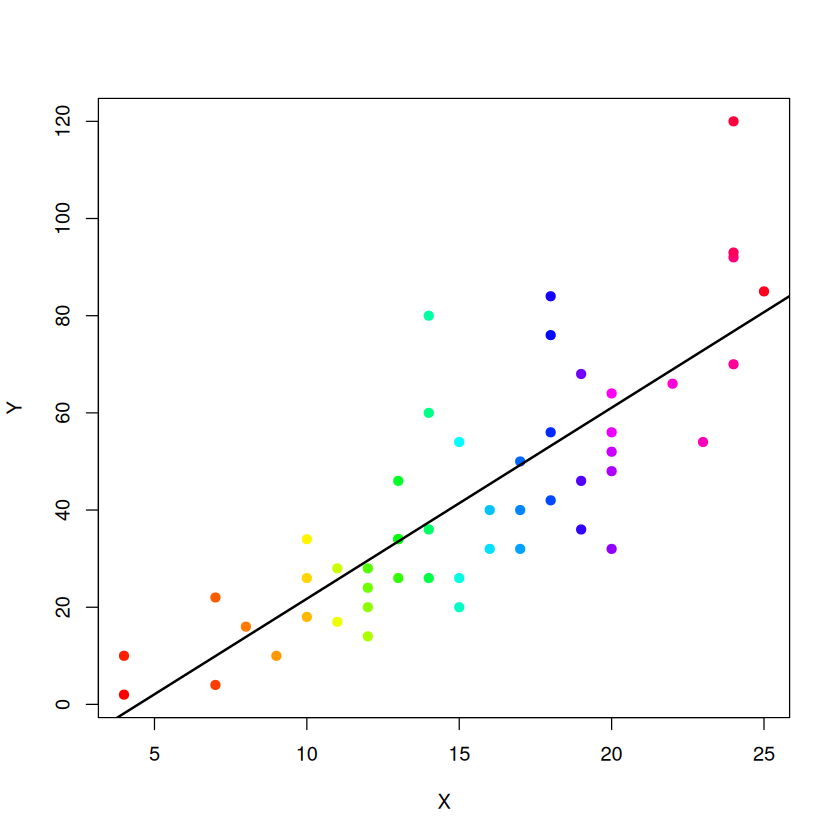

In [18]:
# À FAIRE

# 1
X = cars$speed
Y = cars$dist

# Moyennes
x_bar <- mean(X)
y_bar <- mean(Y)

# Pente
beta1 <- sum((X - x_bar) * (Y - y_bar)) / sum((X - x_bar)^2)

# Ordonnée à l'origine
beta0 <- y_bar - beta1 * x_bar


# 2
linreg <- lm(Y ~ X)

# 3
cor(X,Y, method = "pearson")

# 4
par(bg = "white")
plot(X, Y, type="p", col=rainbow(length(X)), pch=19)
abline(beta0, beta1, lwd = 2)

## 2. Régression linéaire multiple

Le cadre général du modèle de régression linéaire peut être donné par un vecteur $y \in \mathbb{R}^n$ contenant les $n$ observations de la *variable à expliquer* et par une matrice $X \in \mathbb{R}^{n \times p}$ contenant les $n$ observations des $p$ *variables explicatives*. Parmi les variables explicatives, une colonne de 1 est souvent ajoutée pour traiter l'ordonnée à l'origine comme les autres variables et unifier les notations. La relation recherchée se formule à l'aide du *vecteur des coefficients* $\theta \in \mathbb{R}^p$,
\begin{equation*}
y = X\theta + \varepsilon
\end{equation*}
où $\varepsilon \in \mathbb{R}^n$ est le vecteur des résidus. Des calculs similaires à ceux vus en cours pour le critère des moindres carrés donnent la formulation matricielle de l'estimateur $\hat{\theta}$ lorsque la matrice $X^\top X$ est inversible,
\begin{equation*}
\hat{\theta} = (X^\top X)^{-1} X^\top y.
\end{equation*}

Nous considérons maintenant le jeu de données `swiss`.

In [ ]:
help(swiss)

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Effectuer la régression linéaire multiple modélisant la fertilité en fonction des autres variables à l'aide de la fonction <code>lm()</code>.</li>
        <li>Recalculer les coefficients de la régression par la formule matricielle donnée ci-dessus.</li>
        <li>Utiliser la fonction <code>step()</code> pour réduire la dimension du modèle en retirant les variables négligeables.</li>
    </ol>
</div>

In [42]:
# À FAIRE
modele <- lm(Fertility ~ ., data = swiss)

X = as.matrix(swiss[,2:6])
Y = as.matrix(swiss[,1])

X_mat <- cbind(1, X) # Ajout de la colonne de 1 pour l'ordonnée à l'origine
Y <- as.matrix(Y)

beta_hat <- solve(t(X_mat) %*% X_mat) %*% t(X_mat) %*% Y
beta_hat


modele_reduit <- step(modele, direction="both")

,66.9151817
Agriculture,-0.1721140
Examination,-0.2580082
Education,-0.8709401
Catholic,0.1041153
Infant.Mortality,1.0770481


Start:  AIC=190.69
Fertility ~ Agriculture + Examination + Education + Catholic + 
    Infant.Mortality

                   Df Sum of Sq    RSS    AIC
- Examination       1     53.03 2158.1 189.86
<none>                          2105.0 190.69
- Agriculture       1    307.72 2412.8 195.10
- Infant.Mortality  1    408.75 2513.8 197.03
- Catholic          1    447.71 2552.8 197.75
- Education         1   1162.56 3267.6 209.36

Step:  AIC=189.86
Fertility ~ Agriculture + Education + Catholic + Infant.Mortality

                   Df Sum of Sq    RSS    AIC
<none>                          2158.1 189.86
+ Examination       1     53.03 2105.0 190.69
- Agriculture       1    264.18 2422.2 193.29
- Infant.Mortality  1    409.81 2567.9 196.03
- Catholic          1    956.57 3114.6 205.10
- Education         1   2249.97 4408.0 221.43


## 3. Analyse de variance

Dans cette dernière partie, nous utiliserons le jeu de données `iris`.

In [43]:
help(iris)

iris                 package:datasets                  R Documentation

_E_d_g_a_r _A_n_d_e_r_s_o_n'_s _I_r_i_s _D_a_t_a

_D_e_s_c_r_i_p_t_i_o_n:

     This famous (Fisher's or Anderson's) iris data set gives the
     measurements in centimeters of the variables sepal length and
     width and petal length and width, respectively, for 50 flowers
     from each of 3 species of iris.  The species are _Iris setosa_,
     _versicolor_, and _virginica_.

_U_s_a_g_e:

     iris
     iris3
     
_F_o_r_m_a_t:

     ‘iris’ is a data frame with 150 cases (rows) and 5 variables
     (columns) named ‘Sepal.Length’, ‘Sepal.Width’, ‘Petal.Length’,
     ‘Petal.Width’, and ‘Species’.

     ‘iris3’ gives the same data arranged as a 3-dimensional array of
     size 50 by 4 by 3, as represented by S-PLUS.  The first dimension
     gives the case number within the species subsample, the second the
     measurements with names ‘Sepal L.’, ‘Sepal W.’, ‘Petal L.’,

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Représenter les boxplots de chacune des 4 variables en fonction des modalités de la variable <code>Species</code>.<br>
            <center><img src="img/iris.png"></center>
        </li>
        <li>On souhaite appliquer une ANOVA sur chacun des variable quantitative de ce jeux de donnée. Que cherche-t-on à tester ? </li>
        <li>Le bon fonctionnement de l'ANOVA repose sur des hypothèses, quelles sont t'elle ? Mettez en place un tester pour vérifier si elles semble raisonnable sur ce jeux de données. </li>
        <li>Pour chaque variable quantitative du jeu de données <code>iris</code>, utiliser la fonction <code>aov()</code> puis <code>print()</code> et <code>summary()</code> sur le résultat pour appliquer l'ANOVA.</li>
    </ol>
</div>

In [ ]:
# À FAIRE